# Testing out Point Defects

#### Collection of methods

In [ ]:
import veloxchem
import os
from typing import Literal
from ase.io import read, write
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.visualize.plot import plot_atoms
import numpy as np
import veloxchem.ensembledriver
import veloxchem.ensembleparser
import pandas as pd

#from pymodule.ECM_test.tempfiles.main import PDB_FILE, QM_RESNAME

PATH = 'tempfiles'
CHARGE_MAP = {'O': -2, 'C': 0, 'H': 0, 'Na': 1, 'Cl': -1}  
ATOMIC_NUMBERS = {
    'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8,
    'F': 9, 'Ne': 10, 'Na': 11, 'Mg': 12, 'Al': 13, 'Si': 14, 'P': 15,
    'S': 16, 'Cl': 17, 'Ar': 18, 'K': 19, 'Ca': 20,
}
# Change to make user input a molecule object. 
GEOMETRIES = {
    'H2O': "3\n\nO 0.0 0.0 0.117\nH 0.0 0.757 -0.469\nH 0.0 -0.757 -0.469\n",
    'Na':  "1\n\nNa 0.0 0.0 0.0\n",
    'Cl':  "1\n\nCl 0.0 0.0 0.0\n",
    'NaCl': "2\n\nNa 0.0 0.0 0.0\nCl 2.36 0.0 0.0\n",
}

PossiblePhases = Literal['1h', '1c']    
def generate_ice_block(path, phase: PossiblePhases, cell_dimensions, unit_cell_filename, target_supercell_shape, target_supercell_size, write_to_pdb = True, plot = True):
    super_cell_filename = f'{phase}x{cell_dimensions[0]}{cell_dimensions[1]}{cell_dimensions[2]}_supercell'
    # Generate unit.
    '''
    Generate an ice supercell from a unit cell using genice2 and ASE.

    Uses genice2 to create a CIF unit cell of the specified ice phase and
    cell dimensions, then constructs an optimal supercell via ASE. Optionally
    writes the result to a PDB file and/or plots the atomic structure.

    Args:
        path:                    Directory path for output files.
        phase:                   Ice phase identifier ('1h' or '1c').
        cell_dimensions:         Tuple of (a, b, c) repetitions for the unit cell.
        unit_cell_filename:      Base filename for the generated CIF unit cell.
        target_supercell_shape:  Target shape for find_optimal_cell_shape (e.g. 'sc').
        target_supercell_size:   Target number of unit cells in the supercell.
        write_to_pdb:            If True, write the supercell to a PDB file.
        plot:                    If True, display a plot of the supercell atoms.
    '''
    os.system(f'mkdir {path}')
    # os.system('ls')
    os.system(f'genice2 --rep {cell_dimensions[0]} {cell_dimensions[1]} {cell_dimensions[2]} {phase} --format cif > {path}/{unit_cell_filename}.cif')

    # Make Atoms obj. 
    ice = read(
        filename=(f'{path}/{unit_cell_filename}.cif')
        )

    # print(np.asarray(cell))
    P = find_optimal_cell_shape(
        cell=ice.cell, 
        target_size=target_supercell_size,
        target_shape=target_supercell_shape
        )

    ice_block = make_supercell(prim=ice,P=P,)
    
    if write_to_pdb:
        pdb_file = f'{path}/{super_cell_filename}.pdb'
        write(f'{pdb_file}', ice_block)
    
    if plot:
        plot_atoms(ice_block)

# TODO: Generalize this function to output more geometry parameters if necessary
def get_space_dimensions(filename = None):
    
    supercell = read(f'{filename}')
    '''
    Determine the maximum spatial extent of a crystal structure.

    Reads the structure from the given file and finds the maximum x, y, z
    coordinates among all atoms, which approximate the bounding box of the
    supercell.

    Args:
        filename:  Path to the structure file (PDB, CIF, etc.).

    Returns:
        list: [max_x, max_y, max_z] coordinates in Angstroms.
    '''
    np_supercell = np.array(supercell)

    x = 0
    y = 0
    z = 0
    for i in np_supercell:
        ix, iy, iz = i.position
        if ix > x:
            x = ix
        if iy > y:
            y = iy
        if iz > z:
            z = iz
        # print(ix)
    # print(x, y, z)
    return [x, y, z]

# TODO: Simplify to output all indecies in QM region. 
def get_centeroid_region(filename, patterns, cuboid_threshold=None, print_ctrl=True, debug=False):
    '''
    Returns dict mapping resnames to lists of atom indices within the QM cuboid region.
    
    Args:
        filename:          Path to pdb or cif file.
        patterns:          Dict mapping resname to symbol pattern, 
                           e.g. {'WAT': ['O', 'H', 'H'], 'ION': ['Na']}
        cuboid_threshold:  Decimal margin from center to edge of cuboid QM region.
        print_ctrl:        Print real-time status.
    
    Returns:
        Dict like {'WAT': [3, 15, 27], 'ION': [5]} — starting atom indices per resname.
    '''
    supercell = read(f'{filename}')
    if debug: print(f'DEBUG: supercell {supercell}')
    x, y, z = get_space_dimensions(filename)
    
    midpoint = [x/2, y/2, z/2]
    if debug: print(f'DEBUG: x, y, z, midpoint{x, y, z, midpoint}')
    x_threshold = [(midpoint[0] - x * cuboid_threshold), (midpoint[0] + x * cuboid_threshold)]
    y_threshold = [(midpoint[1] - y * cuboid_threshold), (midpoint[1] + y * cuboid_threshold)]
    z_threshold = [(midpoint[2] - z * cuboid_threshold), (midpoint[2] + z * cuboid_threshold)]

    symbols = list(supercell.symbols)
    if debug: print(f'DEBUG: symbols {symbols}')
    qm_candidates = {}

    for resname, pattern in patterns.items():
        candidates = []
        matches = _find_pattern(symbols=symbols, pattern=pattern) # output inital indecies of matched segments in list of symbols. 
        print(f'Checked pattern {pattern}, for residuename {resname}')
        print(f'Found the following indecies {matches}')
        for i in matches: # Checks each given index
            atom = supercell[i]
            ax, ay, az = atom.position  # check position of the first atom
            if (ax < x_threshold[0] or ax > x_threshold[1] or
                ay < y_threshold[0] or ay > y_threshold[1] or
                az < z_threshold[0] or az > z_threshold[1]):
                continue
            for j in range(len(pattern)):
                candidates.append(atom.index + j)
        qm_candidates[resname] = candidates

        if print_ctrl:
            print(f'Pattern {resname} {pattern}: {len(matches)} total, {len(candidates)} in QM region')

    return qm_candidates

# TODO: Draft.



def identify_connectivity_pdb(filename, bonds_length, debug=False):
    import numpy as np
    from ase.io import read
    from scipy.spatial import cKDTree
    from collections import defaultdict

    # 1. Read the supercell
    supercell = read(filename)
    positions = supercell.positions
    symbols = supercell.get_chemical_symbols()

    # 2. Parse bond lengths into a hash map (dictionary) for O(1) lookups
    # Assuming bonds_length is a list of tuples like: [('C', 'O', 1.5), ('H', 'O', 1.2)]
    bond_cutoffs = {}
    max_cutoff = 0.0
    
    for sym1, sym2, length in bonds_length:
        bond_cutoffs[(sym1, sym2)] = length
        bond_cutoffs[(sym2, sym1)] = length  # Account for both directions
        max_cutoff = max(max_cutoff, length) # Find the absolute longest bond

    # 3. Use a KD-Tree to find all pairs within the maximum possible cutoff
    # This completely eliminates the O(N^2) nested loop bottleneck.
    tree = cKDTree(positions)
    pairs = tree.query_pairs(r=max_cutoff)

    # 4. Build an Adjacency List (Graph)
    graph = defaultdict(list)
    
    for i, j in pairs:
        sym_i, sym_j = symbols[i], symbols[j]
        
        # Check if this specific pair of elements has a defined bond rule
        if (sym_i, sym_j) in bond_cutoffs:
            dist = np.linalg.norm(positions[i] - positions[j])
            
            # If distance is within the specific bond length, connect them
            if dist <= bond_cutoffs[(sym_i, sym_j)]:
                graph[i].append(j)
                graph[j].append(i)

    # 5. Find Connected Components (Collections of atoms)
    # This groups the connected graph into separate molecules/clusters
    visited = set()
    collections = []

    for atom_idx in range(len(supercell)):
        if atom_idx not in visited:
            # Start a Breadth-First Search (BFS) to find the whole molecule
            molecule = []
            queue = [atom_idx]
            visited.add(atom_idx)

            while queue:
                current_atom = queue.pop(0)
                molecule.append(current_atom)
                
                # Check all neighbors of the current atom
                for neighbor in graph[current_atom]:
                    if neighbor not in visited:
                        visited.add(neighbor)
                        queue.append(neighbor)
            
            # Add the completed molecule to our collections
            collections.append(molecule)

    if debug:
        print(f"Total atoms: {len(supercell)}")
        print(f"Total separate collections found: {len(collections)}")

    return collections

def process_pdb_advanced(filename, mol_residues, qm_resname='LIG', qm_threshold=0.1, debug = False, clear_unmatched = False):
    from ase.io import read
    
    # Access each molecular residue, Identify lneght. Remove any indcies not in collection. 
    # Tasks to complete:
    # 1. Delete unconsidered atoms.
    # 2. Assign qm atoms by assessing wether a collection has a median position within the threshold. 
    # 3. Update and output a new file. 

    # Method:
    # Itteate through all given data. 
    # Reference the respective data lines. Note to always keep track of the offest between line indecies and atom indecies. Note also that atom indecies are 0-based. 
    # Proposal:
    # Eneter each collection. 
    # Check the length.
    # If lenght is off and clearing is True, delete the respective line entries and record the offset somehow. Maybe set the line to blank? 
    # If clearing is False, do something else. 
    # if lneght is good,
    # Check the median position of the collection. 
    # If in qm, 
    # Set the qm resname for each index. 
    # while in both cases, the next resnumber is assigned. 
    # When done, write lines to output file. 
    
    if debug: print(f'DEBUG: Running process_pdb_advanced on {filename}')
    with open(filename) as f:
        lines = f.readlines()
    out = []

    crystal = read(filename)

    # Identify ATOM data region
    start_idx = None
    end_idx = None
    for i, line in enumerate(lines):
        if line.startswith('ATOM'):
            if start_idx is None:
                start_idx = i
            end_idx = i
            if clear_unmatched: out.append(' \n') # append empty
            else: out.append(line)
        else: 
            out.append(line)
    if start_idx is None:
        print('No ATOM lines found.')
        return

    # 0. GET SYSTEM CENTER
    x, y, z = get_space_dimensions(filename=filename)
    midpoint = [x/2, y/2, z/2]
    if debug: print(f'DEUBG: Model midpoint {midpoint}')

    # 0. EDGE CASE CHECK    
    curr_residue_id = 1
    if clear_unmatched: curr_residue_id = 2

    if (len(qm_resname) > 3):
        raise ValueError('Residue names must be 3 characters long.')
    if debug:
        print(f'DEBUG: curr_residue_id {curr_residue_id}')
        print(f'DEBUG: qm_resname {qm_resname}')
        print(f'DEBUG: qm_threshold {qm_threshold}')
        # print(f'DEBUG: mol_residues {mol_residues}')
        # print(f'DEBUG: All lines in the file {lines}')

    # 1. CHECK FOR INCOMPLETE MOLECULES
    delete_indices = []
    qm_indices = []
    for resname, val in mol_residues.items():
        if debug:
            print(f'DEBUG: resname {resname}')
            print(f'DEBUG: num_colects {len(val[0])}')
            print(f'DEBUG: res_len {val[1]}')
        # Regard the residue length and collection.
        colects = val[0]  # Colelction of atom indecies belong to a particular molecule.
        res_len = val[1]
        
        # 1.2. ChECK INCOMPLETE MOLECULES CONDITION
        for collect in colects:
            if len(collect) != res_len:
                print(f'Length of collection {resname} does not match the expected length {res_len}.')
                print(f'Length of collection {resname} is {len(collect)}.')
                for atom_idx in collect:
                    if debug: print(f'DEBUG: Marked atom {atom_idx} for deletion')
                    delete_indices.append(atom_idx)
        
            # Assign QM Atoms # NOTE Draft. Only assign env resnames for now. 
            if len(collect) == res_len:
                if debug: print(f'DEBUG: Starting process for {collect}')
                # 3. FIND COLLECTION CENTER

                
                positions = [crystal[atom_idx].position for atom_idx in collect]
                totle_pos = np.zeros(3)
                for i in positions:
                    totle_pos += i
                mean_pos = totle_pos / len(positions)
                
                if (
                    midpoint[0] - x*qm_threshold < mean_pos[0] < midpoint[0] + x*qm_threshold and
                    midpoint[1] - y*qm_threshold < mean_pos[1] < midpoint[1] + y*qm_threshold and
                    midpoint[2] - z*qm_threshold < mean_pos[2] < midpoint[2] + z*qm_threshold
                ):
                    curr_res_name = qm_resname
                    qm_indices.append(collect)
                else:
                    curr_res_name = resname

                for i in collect:
                    line_idx = start_idx + i 
                    curr_line = lines[line_idx]
                    # Pad curr_residue_id string to length 4 for standard PDB format alignment
                    res_id_str = str(curr_residue_id).rjust(4)
                    new_line = curr_line[:17] + curr_res_name + curr_line[20:22] + res_id_str + curr_line[26:] # Overwrite res name.
                    out[line_idx] = new_line
                
                curr_residue_id += 1
        
    # Ensure that all atoms of the same residue appear contiguously in the final file, 
    # and maintain identical inner-residue alphabetical ordering for VeloxChem sanity.
    non_atoms = [l for l in out if not l.startswith('ATOM')]
    valid_atoms = [l for l in out if l.startswith('ATOM') and l.strip() != '']

    from collections import defaultdict
    residue_map = defaultdict(list)
    for line in valid_atoms:
        try:
            rid = int(line[22:26])
        except:
            rid = 0
        residue_map[rid].append(line)
    
    # 1. Sort by Residue ID to guarantee contiguity
    # 2. Sort inner atoms by element/alphabetical name to ensure unified pattern across all resid instances
    final_ordered_atoms = []
    for rid in sorted(residue_map.keys()):
        group = residue_map[rid]
        group.sort(key=lambda l: (l[76:78].strip() or l[13:14], l[30:38])) # Sort by element then X-coord for stability
        final_ordered_atoms.extend(group)

    # Renumber total atom index count from 1 to avoid gaps/shuffled IDs
    for i, l in enumerate(final_ordered_atoms):
        final_ordered_atoms[i] = l[:6] + f'{(i+1):5d}' + l[11:]
    
    # Re-stitch the finalized file structure
    atom_marker_idx = 0
    for i, line in enumerate(out):
        if line.startswith('ATOM'):
            atom_marker_idx = i
            break
    
    header = out[:atom_marker_idx]
    footer = [l for l in out[atom_marker_idx:] if not l.startswith('ATOM')]
    
    # Replace "out" with fully rectified sequence
    out = header + final_ordered_atoms + footer
    
    with open(filename, 'w') as f:
        f.writelines(out)

    # Disover the actual new indices that made it into the finalized output
    final_qm_map = {}
    atom_count = 0
    for line in out:
        if line.startswith('ATOM'):
            # Use exact PDB column offsets to read values injected earlier
            injected_resname = line[17:20].strip()
            injected_resid = line[22:26].strip()
            if injected_resname == qm_resname:
                if injected_resid not in final_qm_map:
                    final_qm_map[injected_resid] = []
                final_qm_map[injected_resid].append(atom_count)
            atom_count += 1
            
    return list(final_qm_map.values())


                
            # totle_pos = np.zeros(3)
            # for i in colect:
            #     totle_pos += i.get_positions()
            # mean_pos = totle_pos / len(colect)

            
            

                

    
    
    

def process_pdb(filename, patterns, qm_ids=None, qm_resname=None):
    """
    Process a PDB file, assigning residue names and unique residue numbers
    to atoms matching specified patterns.

    Args:
        filename:   Path to the PDB file.
        patterns:   Dict mapping residue names to atom symbol patterns.
                    e.g. {'WAT': [' O', ' H', ' H'], 'ION': [' Na']}
        qm_ids:     Optional list of atom indices whose residue name
                    should be overridden with qm_resname.
        qm_resname: Residue name for QM-region molecules (e.g. 'LIG').
    """
    if qm_ids is None:
        qm_ids = {}

    print(f'Processing {filename}')
    with open(filename) as f:
        lines = f.readlines()

    # Identify ATOM data region
    start_idx = None
    end_idx = None
    for i, line in enumerate(lines):
        if line.startswith('ATOM'):
            if start_idx is None:
                start_idx = i
            end_idx = i

    if start_idx is None:
        print('No ATOM lines found.')
        return

    print(f'Data row index limits: Start: {start_idx}; End: {end_idx}')

    # Extract atom symbols from the ATOM region
    symbols = [line[14:16].strip() for line in lines[start_idx:end_idx + 1]]

    # Find all matching segments for every pattern
    matches = []  # (line_index, pattern_length, resname)
    for resname, pattern in patterns.items():
        for idx in _find_pattern(symbols, pattern, offset=start_idx):
            matches.append((idx, len(pattern), resname))

    # Sort by line index so residue are assigned in file order
    matches.sort(key=lambda x: x[0])
    print(f'Found {len(matches)} matching segments.')
    print(f'-> \t{matches}')

    # Assign residue names and unique residue numbers
    print(f'Lines before residue reassignments: {lines}')
    res_num = 2
    for seg_idx, pat_len, resname in matches:
        print(f'DOING {resname} at segment with index {seg_idx} with pattern length {pat_len}')
        res_num_str = f'{res_num:>4}'
        # Check if this segment's index is in the QM list for its resname
        # (must use original resname key before padding)
        residue_name = resname
        if qm_resname is not None and (seg_idx-start_idx) in qm_ids.get(resname, []):
            residue_name = qm_resname
        # Pad residue name to 3 chars for PDB column alignment
        if len(residue_name) < 3:
            residue_name = f' {residue_name}'
        for i in range(pat_len):
            line = lines[seg_idx + i]
            lines[seg_idx + i] = line[:17] + residue_name + line[20:22] + res_num_str + line[26:]
        res_num += 1

    with open(filename, 'w') as f:
        f.writelines(lines)
    print(f'Lines after residue reassignments:  {lines}')

    print(f'Done. Assigned {res_num - 2} residues.')

def _find_pattern(symbols, pattern, offset=0):
    """
    Find all non-overlapping occurrences of pattern in symbols.
    Returns a list of absolute line indices (adjusted by offset).
    """
    matches = []
    i = 0
    while i <= len(symbols) - len(pattern):
        if symbols[i:i + len(pattern)] == pattern:
            matches.append(i + offset)
            i += len(pattern)  # skip past this match to avoid overlap
        else:
            i += 1
    return matches

def minimum_image_unwrap(filename):
    """
    Unwrap molecules split across periodic boundaries in a PDB file.
    For each residue, shifts all atoms to be within half a cell length
    of the first atom in that residue (the minimum image convention).
    
    Must be called AFTER process_pdb has assigned correct residue numbers.
    Modifies the file in place.
    """
    with open(filename) as f:
        lines = f.readlines()

    # Extract cell dimensions from the CRYST1 record
    cell = None
    for line in lines:
        if line.startswith('CRYST1'):
            cell = [float(line[6:15]), float(line[15:24]), float(line[24:33])]
            break

    if cell is None:
        print('No CRYST1 record found. Cannot unwrap.')
        return

    # Group ATOM lines by (chain ID, residue number)
    residues = {}
    for i, line in enumerate(lines):
        if line.startswith('ATOM') or line.startswith('HETATM'):
            key = line[21:26]  # chain ID + residue seq number
            if key not in residues:
                residues[key] = []
            residues[key].append(i)

    # For each residue, unwrap atoms relative to the first atom
    n_fixed = 0
    for key, atom_indices in residues.items():
        if len(atom_indices) < 2:
            continue

        # Reference position = first atom in the residue (e.g. the Oxygen)
        ref_line = lines[atom_indices[0]]
        ref_pos = [float(ref_line[30:38]), float(ref_line[38:46]), float(ref_line[46:54])]

        for idx in atom_indices[1:]:
            line = lines[idx]
            pos = [float(line[30:38]), float(line[38:46]), float(line[46:54])]
            fixed = False

            for ax in range(3):
                diff = pos[ax] - ref_pos[ax]
                if diff > cell[ax] / 2:
                    pos[ax] -= cell[ax]
                    fixed = True
                elif diff < -cell[ax] / 2:
                    pos[ax] += cell[ax]
                    fixed = True

            if fixed:
                lines[idx] = line[:30] + f'{pos[0]:8.3f}{pos[1]:8.3f}{pos[2]:8.3f}' + line[54:]
                n_fixed += 1

    with open(filename, 'w') as f:
        f.writelines(lines)

    print(f'Unwrapped {n_fixed} atoms across {len(residues)} residues in {filename}.')
    
def del_atoms_pdb(filename, qm_resname, output_filename, delete_indecies):
    '''
    Remove specific atoms from a PDB file to create a defect structure.

    Deletes the atoms at the given indices from the PDB, reindexes the
    remaining ATOM records sequentially, and rebuilds the list of QM-region
    atom indices based on residue name. Writes the modified structure to a
    new output file.

    Args:
        filename:          Path to the input PDB file.
        qm_resname:        Residue name identifying QM-region atoms (e.g. 'LIG').
        output_filename:   Path for the output defect PDB file.
        delete_indecies:   List of 0-based atom indices to remove.

    Returns:
        tuple: (defect, new_qm_candidates)
            - defect (ase.Atoms): ASE Atoms object of the deleted atoms.
            - new_qm_candidates (list[int]): Updated 1-based atom indices
              belonging to the QM region in the output file.
    '''
    defect = read(filename)[delete_indecies]
    # Extract each line in the file. 
    with open(filename) as f:
        lines = f.readlines()
    # Itterate and processes relevant lines. 
    old_atom_index = 0
    new_index = 1

    new_qm_candidates = []  # Save new QM atom candidates here.
    i = 0                   # Track lines line index.
    out = lines.copy()     # Copy original lines list to output list. To be modified... 
    offset = 0
    for i, line in enumerate(lines):
        # print(f'--> ENTERING LINE: {line} \nCURRENT OUTPUT LINE: {out[i-offset]} ')
        if line.startswith('ATOM') == False:
            continue

        if old_atom_index in delete_indecies:       # Check if atom of current line is in target ids. 
            del out[i-offset]                                                         # If yes, delete the line from output list. This should switch the entries in the output list up. 
            offset += 1
        if old_atom_index not in delete_indecies:   # Check if atom of current line is not in target ids.
            # Updated line index
            new_index_str = str(new_index).rjust(4)
            out[i-offset] = line[:7] + new_index_str + line[11:]                       # Insert the updated atom index in the atom index columns of the pdb line. 
            # print(f'APPENDED LINE: {out[i]}')
            # Update qm candidate list
            if line[17:20] == qm_resname:                                       # Check the ligand name of the current name between at the specified columns. 
                # print(f'Atom in QM region found at index {new_index}')          
                new_qm_candidates.append(new_index)                             # Append the index the new qm candidates list. 
            new_index += 1

        old_atom_index +=1
        # Go to next line and observe the respective (old) atom index.
        
        #i += 1                                                                  # Itterate the global loop index. 
    
    with open(output_filename, 'w') as f:
        f.writelines(out)
    return defect, new_qm_candidates

def calc_charge_multiplicity(filename, qm_resname, charge_map, atomic_numbers=ATOMIC_NUMBERS):
    """
    Calculate the net formal charge and spin multiplicity of the QM region
    by reading the PDB and identifying QM atoms by their residue name.

    This approach is robust to atom deletions (defect cells) because it
    relies on residue labels baked into the PDB, not on atom indices.

    Args:
        filename:     Path to the PDB file.
        qm_resname:   Residue name used for QM region (e.g. 'LIG').
        charge_map:   Dict mapping atom symbols to formal charges,
                      e.g. {'Na': 1, 'Cl': -1, 'O': -2, 'H': 1}

    Returns:
        tuple: (qm_charge, qm_multiplicity)
            - qm_charge (int): Net formal charge of the QM region.
            - qm_multiplicity (int): Spin multiplicity (1 = singlet, 2 = doublet, ...).
              Assumes lowest-spin ground state: even electrons → 1, odd → 2.
    """
    qm_charge = 0
    total_electrons = 0

    with open(filename) as f:
        for line in f:
            if line.startswith('ATOM') or line.startswith('HETATM'):
                resname = line[17:20].strip()
                if resname == qm_resname:
                    # Extract element symbol from cols 76-78 (standard PDB)
                    # PDB uses uppercase (NA, CL); capitalize() → proper case (Na, Cl)
                    symbol = line[76:78].strip().capitalize()
                    qm_charge += charge_map.get(symbol, 0)
                    total_electrons += atomic_numbers.get(symbol, 0)

    # Actual electron count = nuclear electrons minus net charge
    # (positive charge means fewer electrons, negative means more)
    actual_electrons = total_electrons - qm_charge

    # Lowest-spin assumption: even e⁻ → singlet (1), odd e⁻ → doublet (2)
    qm_multiplicity = 1 if actual_electrons % 2 == 0 else 2

    return qm_charge, qm_multiplicity

# NOTE: Draft
def calc_ernergy_fermi(filename):
    '''
    Calculate the Fermi energy (E_F) of the system.

    Placeholder for future implementation. The Fermi energy is needed
    for charged-defect formation energy corrections:
        E^f[X^q] = ... + q[E_F + E_v + δV]

    Args:
        filename:  Path to the input structure or calculation file.

    Returns:
        None (not yet implemented).
    '''
    return

# NOTE: Draft
def calc_vbm_energy(scf_results_perfect):
    '''
    Approximate E_VBM from the HOMO eigenvalue of the perfect cell.
    '''
    mo_energies = scf_results_perfect.get('mo_energies', None)
    n_occupied = scf_results_perfect.get('n_occupied', None)
    
    if mo_energies is not None and n_occupied is not None:
        e_vbm = mo_energies[n_occupied - 1]
        print(f'E_VBM (HOMO) = {e_vbm:.10f} Hartree')
        return e_vbm
    
    print('WARNING: Could not extract HOMO energy. Using 0.')
    return 0.0

# NOTE: Drat
def calc_potential_alignment(scf_results_perfect, scf_results_defect):
    '''
    Placeholder for ΔV. Set to 0 initially; refine later with
    VeloxChem's electrostatic potential data.
    '''
    print('WARNING: ΔV = 0 (placeholder)')
    return 0.0


# NOTE: Draft
def calc_chemical_potential(species, geometries, basis_set='6-31G', dispersion = False):
    '''
    Compute isolated atom/molecule energy as chemical potential reference.
    Uses unrestricted SCF for open-shell species (Na, Cl).
    '''
    import veloxchem as vlx

    mol = vlx.Molecule.read_xyz_string(geometries.get(species, species))
    bas = vlx.MolecularBasis.read(mol, basis_set)

    if mol.number_of_electrons() % 2 == 0:
        scf_drv = vlx.ScfRestrictedDriver()
        mol.set_multiplicity(1)
    else:
        scf_drv = vlx.ScfUnrestrictedDriver()
        mol.set_multiplicity(2)

    scf_drv.conv_thresh = 1.0e-6
    scf_drv.dispersion = dispersion
    scf_drv.compute(mol, bas)
    energy = scf_drv.get_scf_energy()
    print(f'μ({species}) at HF/{basis_set} = {energy:.10f} Hartree')
    return energy


# NOTE: Draft
def find_schottky_pair_qm(filename, qm_indices):
    '''
    Find a Na-Cl pair WITHIN the QM region to delete for a Schottky defect.
    Both atoms must be in the QM region (labeled LIG).
    
    The vacancy is in the QM region; μ(Na) + μ(Cl) compensate.
    This is consistent with the ice approach where a LIG molecule
    is deleted and μ(H₂O) compensates.
    '''
    from ase.io import read
    import numpy as np

    supercell = read(filename)
    pos = supercell.get_positions()
    sym = list(supercell.symbols)

    # Find Na and Cl atoms WITHIN the QM region
    na_qm = [i for i in qm_indices if sym[i] == 'Na']
    cl_qm = [i for i in qm_indices if sym[i] == 'Cl']

    if not na_qm or not cl_qm:
        raise ValueError('QM region must contain at least one Na AND one Cl for a Schottky pair')

    # Pick the Na-Cl pair with shortest distance (nearest neighbors)
    best_pair = None
    best_dist = float('inf')
    for na_i in na_qm:
        for cl_i in cl_qm:
            d = np.linalg.norm(pos[na_i] - pos[cl_i])
            if d < best_dist:
                best_dist = d
                best_pair = (na_i, cl_i)

    print(f'Schottky pair (from QM region):')
    print(f'  Na idx={best_pair[0]}, Cl idx={best_pair[1]}, dist={best_dist:.3f} Å')
    return list(best_pair)


# NOTE: Draft
def find_single_vacancy_qm(filename, qm_indices, target_species='Na'):
    '''
    Find an atom of target_species WITHIN the QM region to delete.
    The vacancy is in the QM region; μ(species) compensates.
    '''
    from ase.io import read
    import numpy as np

    supercell = read(filename)
    sym = list(supercell.symbols)

    candidates = [i for i in qm_indices if sym[i] == target_species]

    if not candidates:
        raise ValueError(f'No {target_species} atom found in QM region')

    # Pick the first candidate (or could pick one closest to centroid)
    target = candidates[0]
    print(f'{target_species} vacancy (from QM region): idx={target}')
    return [target]

    
# NOTE: Deterministic
def calc_chemical_potential_h2o(basis_set='6-31G'):
    '''
    Compute the energy of an isolated H2O molecule at the given level of theory.
    This serves as the chemical potential μ(H₂O) for the formation energy formula:
        E_f = E[defect] - E[perfect] + μ(H₂O)
    '''
    import veloxchem as vlx

    # Standard water geometry (Angstrom)
    water_xyz = """3

    O   0.000   0.000   0.117
    H   0.000   0.757  -0.469
    H   0.000  -0.757  -0.469
    """

    mol = vlx.Molecule.read_xyz_string(water_xyz)
    bas = vlx.MolecularBasis.read(mol, basis_set)

    scf_drv = vlx.ScfRestrictedDriver()
    scf_results = scf_drv.compute(mol, bas)

    energy = scf_drv.get_scf_energy()
    print(f'μ(H₂O) at HF/{basis_set} = {energy:.10f} Hartree')
    return energy

def calc_energy_tot(filename, qm_resname, pe_cutoff=6.0, npe_cutoff=None, qm_charge=0, qm_multiplicity=1, pe_model = 'SEP', npe_model='tip3p', dispersion = False):
    print("Ensemble parser instance created.")
    ep = veloxchem.ensembleparser.EnsembleParser()   
    '''
    Compute the total SCF energy of a crystal structure using QM/PE embedding.

    Parses the PDB trajectory file via VeloxChem's EnsembleParser, sets up
    polarizable embedding (PE) with the SEP model and non-polarizable
    embedding (NPE) with TIP3P, then runs a restricted Hartree-Fock SCF
    calculation using the 6-31G basis set.

    Args:
        filename:          Path to the PDB trajectory file.
        qm_resname:        Residue name identifying the QM region (e.g. 'LIG').
        pe_cutoff:         Cutoff distance (Å) for polarizable embedding.
        npe_cutoff:        Cutoff distance (Å) for non-polarizable embedding,
                           or None to disable NPE.
        qm_charge:         Net formal charge of the QM region.
        qm_multiplicity:   Spin multiplicity of the QM region (1 = singlet).

    Returns:
        dict: SCF results dictionary from EnsembleDriver.compute(),
              containing energies accessible via
              result['scf_all'][snapshot][frame]['scf_energy'].
    '''
    ed = veloxchem.ensembledriver.EnsembleDriver()
    
    ensemble = ep.structures(
        trajectory_file = f"{filename}",
        num_snapshots = None, 
        qm_region = f"resname {qm_resname}", 
        pe_cutoff = pe_cutoff,
        npe_cutoff=npe_cutoff
    )
    if pe_model != None and npe_model != None or pe_cutoff != None or npe_cutoff != None:
        ed.set_env_models(pe_model = pe_model, npe_model=npe_model)
    elif pe_model != None:
        ed.set_env_models(pe_model = pe_model)
    elif npe_model != None:
        ed.set_env_models(npe_model = npe_model)

    # Enable dispersion on the underlying SCF driver
    ed.update_settings(scf_dict={'dispersion': dispersion, 'max_iter': 150})

    # TODO: Testa att sätta ed.xcfun = 'B3LYP'
    #ed.xcfun = 'B3LYP'
    scf_results = ed.compute(ensemble, basis_set = '6-31G', qm_charge=qm_charge, qm_multiplicity=qm_multiplicity)
    return scf_results
    
# NOTE: Draft.
def calc_energy_tot_relaxed(filename, qm_resname, pe_cutoff=6.0, 
                            qm_charge=0, qm_multiplicity=1,
                            basis_set='6-31G'):
    import veloxchem as vlx
    
    # 1. Parse the structure (reuse EnsembleParser for coordinate extraction)
    ep = vlx.EnsembleParser()
    snapshots = ep.structures(
        trajectory_file=filename,
        qm_region=f"resname {qm_resname}",
        pe_cutoff=pe_cutoff
    )
    snap = snapshots[0]
    
    # 2. Build molecule + basis
    mol = vlx.Molecule(snap['qm_elements'], snap['qm_coords'])
    mol.set_charge(qm_charge)
    mol.set_multiplicity(qm_multiplicity)
    bas = vlx.MolecularBasis.read(mol, basis_set)
    #print(f'DEBUG: Moelcular coordinates: {mol.get_positions()}')
    print(f'Molecualr basis: {bas}')
    
    # 3. Write PE potfile (reuse EnsembleDriver's writer)
    ed = vlx.EnsembleDriver()
    ed.set_env_models(pe_model='SEP', npe_model='tip3p')
    ed.write_pot_files([snap], outdir='pot_frames')
    
    # 4. Configure SCF driver with PE
    scf_drv = vlx.ScfRestrictedDriver()
    scf_drv.potfile = f'pot_frames/pe_frame_{snap["frame"]:06d}.pot'
    
    # 5. Run geometry optimization (uses ScfGradientDriver + PE grad internally)
    opt_drv = vlx.OptimizationDriver(scf_drv)
    opt_drv.max_iter = 100
    opt_results = opt_drv.compute(mol, bas) # NOTE: SCF did not converge, need to fix this
    
    # 6. Get relaxed energy
    final_mol = opt_results['final_molecule']
    scf_drv.compute(final_mol, bas)
    energy = scf_drv.get_scf_energy()
    
    return energy, opt_results


def calc_formation_energy(filename_perf, filename_defect, qm_resname,
                          chemical_potentials,
                          charge_state=0,
                          e_fermi=0.0, e_vbm=0.0, delta_v=0.0,
                          pe_cutoff=None, npe_cutoff=None,
                          charge_map=CHARGE_MAP, dispersion = False, 
                          debug=False):
    '''
    Van de Walle formation energy:
    E_f = E[def] - E[perf] + Σ nᵢμᵢ + q(E_F + E_VBM + ΔV)
    
    The vacancy is IN the QM region. The chemical potential terms
    compensate for the removed QM atoms (large cancellation expected).
    
    Args:
        chemical_potentials: dict {species: (count, mu)}
            Ice:     {'H2O': (1, mu_h2o)}
            Schottky: {'Na': (1, mu_na), 'Cl': (1, mu_cl)}
            Na-vac:  {'Na': (1, mu_na)}
        charge_state: int q (0 for neutral, ±1 for charged)
        e_fermi: Fermi energy in Ha (only matters when q≠0)
        e_vbm:   VBM energy in Ha (only matters when q≠0)
        delta_v:  potential alignment in Ha (only matters when q≠0)
    '''
    HARTREE_TO_EV = 27.211386245988

    # 1. Perfect lattice
    print('1.\tPERFECT LATTICE')
    ch_p, mu_p = calc_charge_multiplicity(
        filename=filename_perf, qm_resname=qm_resname, charge_map=charge_map)
    res_p = calc_energy_tot(filename=filename_perf, qm_resname=qm_resname,
        pe_cutoff=pe_cutoff, qm_charge=ch_p, qm_multiplicity=mu_p, npe_cutoff=npe_cutoff,
        dispersion=dispersion)
    
    if debug:
        print(f'DEBUG: res_p {res_p}')

    E_perf = res_p['scf_all'][0][1]['scf_energy']
    print(f'  \tE_perf = {E_perf:.10f} Ha (q={ch_p}, mult={mu_p})')

    # 2. Defect lattice  
    print('2.\tDEFECT LATTICE')
    ch_d, mu_d = calc_charge_multiplicity(
        filename=filename_defect, qm_resname=qm_resname, charge_map=charge_map)
    res_d = calc_energy_tot(filename=filename_defect, qm_resname=qm_resname,
        pe_cutoff=pe_cutoff, qm_charge=ch_d, qm_multiplicity=mu_d, npe_cutoff=npe_cutoff,
        dispersion=dispersion)
        
    E_def = res_d['scf_all'][0][1]['scf_energy']
    print(f'  \tE_def  = {E_def:.10f} Ha (q={ch_d}, mult={mu_d})')

    # 3. Chemical potentials
    mu_sum = sum(n * mu for n, mu in chemical_potentials.values())
    print('3.\tΣ nᵢμᵢ')
    for sp, (n, mu) in chemical_potentials.items():
        print(f'  \t{sp}: n={n}, μ={mu:.6f} Ha')

    # 4. Charged correction
    q = charge_state
    q_corr = q * (e_fermi + e_vbm + delta_v)
    if q != 0:
        print(f'4.\tCHARGED CORRECTION (q={q})')
        print(f'  \tq·(E_F + E_VBM + ΔV) = {q_corr:.6f} Ha')

    # 5. Result
    dE = E_def - E_perf
    E_f = dE + mu_sum + q_corr

    print(f'\n=== FORMATION ENERGY ===')
    print(f'  ΔE      = {dE:.10f} Ha')
    print(f'  Σnᵢμᵢ  = {mu_sum:.10f} Ha')
    if q != 0: print(f'  q·corr  = {q_corr:.10f} Ha')
    print(f'  E_f     = {E_f:.10f} Ha = {E_f * HARTREE_TO_EV:.6f} eV')
    return {'output':{'E_f':E_f, 'dE':dE, 'mu_sum':mu_sum, 'q_corr':q_corr}, 'perf_scf': res_p, 'defect_scf': res_d}



/opt/anaconda3/envs/vlxenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Testing Point Defects in Ice 1h

### Generate ice block of appropriate size

Specify some general parameters

In [ ]:
UNIT_CELL_DIMENSIONS = (2,1,1)
GENERAL_FILE_NAME = f'1hx{UNIT_CELL_DIMENSIONS[0]}{UNIT_CELL_DIMENSIONS[1]}{UNIT_CELL_DIMENSIONS[2]}'
PDB_FILE = f'{PATH}/{GENERAL_FILE_NAME}.pdb'
DEFECT_PDB_FILE = f'{PATH}/defect_{GENERAL_FILE_NAME}.pdb'

Generate the ice

In [ ]:
os.system(f'genice2 --rep {UNIT_CELL_DIMENSIONS[0]} {UNIT_CELL_DIMENSIONS[1]} {UNIT_CELL_DIMENSIONS[2]} 1h --format cif > {PATH}/{GENERAL_FILE_NAME}.cif')
atoms = read(f'{PATH}/{GENERAL_FILE_NAME}.cif')

write(f'{PDB_FILE}', atoms)

Identify centroid molcuels to set as QM region

In [ ]:
# Read from PDB to maintain coordiate standards.
candidate_qm_water = get_centeroid_region(
    #print_status=False, 
    filename=PDB_FILE, 
    cuboid_threshold = 0.2, 
    patterns={'WAT':['O', 'H', 'H']}
    )
    
print(candidate_qm_water)

Modify PDB file and set QM region based on the results above. 

In [ ]:
process_pdb(
    filename='tempfiles/1hx211.pdb',
    patterns={'WAT': [' O', ' H', ' H']},
    qm_ids=candidate_qm_water,
    qm_resname='LIG'
)

Unwrap molecules in pdb file

In [ ]:
minimum_image_unwrap('tempfiles/1hx211.pdb')

Delete specific water atom

In [ ]:
# defect_ice_block = ice_block
print(candidate_qm_water)
indecies = candidate_qm_water['WAT']
target = indecies[:3]
print(f'Target: {target}')
defect, up_candidate_qm_water = del_atoms_pdb(
    filename=PDB_FILE,
    output_filename=DEFECT_PDB_FILE,
    delete_indecies=target,
    qm_resname='LIG'
)

DEFECT_PDB_FILE
print('ATOMS deleted')
print(f'Defect {defect}')
print(f'New qm candidate list {up_candidate_qm_water}')

plot_atoms(read(filename=DEFECT_PDB_FILE))

### Calcualte formation energy of vacancy:


**Equation(S)**

**From* https://pubs.aip.org/aip/jap/article/95/8/3851/472904/First-principles-calculations-for-defects-and?guestAccessKey=*

$E^f[X^q]=E_{tot}[X^q]-E_{tot}[Mol,bulk]-\sum_i n_i µ_i+q[E_F+E_v+∂V]$

$E_{tot}[X]$ is total energy derived from supercell calcualtions with an inpurity introduced, where $X$ simply symbolizes the impurtity.

$E_{tot}[Mol,bulk]$ represents the correspnding total energy of the undisturbed lattice. 

$n_i$ is the number of atoms of each type that has been added or removed ($n_i<1$ in case of removal of particle). In some cases impurities are itnroduced as additional particles, in which case types i are the host particles and the inpurity. 

$µ_i$ is the corresponding chemical potential of these species. In case of the removal of a host particel, then µ_i is the chemcial potential of an individual host particle.

$E_F$ is the so called "Fermi level".

$E_V$ is the formation energy of charged states. How relevant this is for various different systems is out of my knowledge. 

In [ ]:
# Compute μ(H₂O) at same level of theory (HF/6-31G)
mu_h2o = calc_chemical_potential_h2o(basis_set='6-31G')

# Compute formation energy
E_f = calc_formation_energy( 
    filename_perf=PDB_FILE,
    filename_defect=DEFECT_PDB_FILE,
    qm_resname='LIG',
    chemical_potentials = {'H2O': (1, mu_h2o)},  # Temporary variable implemented before I figure out how to generalize the chemcial potential generation. 
    pe_cutoff=16.0,
    npe_cutoff=None,
    charge_map=CHARGE_MAP
)

## Testing Point Defects in NaCl (ionic and pair defects)

In [ ]:
from ase.build import bulk
from ase.spacegroup import crystal
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.visualize.plot import plot_atoms
from ase.io import read, write

In [ ]:
PATH = 'tempfiles/'
GENERAL_FILE_NAME_NACL = 'supercell_nacl'
DEFECT_FILE_NAME_NACL = f'defect_{GENERAL_FILE_NAME_NACL}'
CIF_FILE_NACL = f'{PATH}/{GENERAL_FILE_NAME_NACL}.cif'
PDB_FILE_NACL = f'{PATH}/{GENERAL_FILE_NAME_NACL}.pdb'
DEFECT_PDB_NACL = f'{PATH}/{DEFECT_FILE_NAME_NACL}.pdb'

Generate supercell and write and get centroid region

In [ ]:
#from scipy._lib.cobyqa.subsolvers.optim import qr_normal_byrd_omojokun

# nacl = crystal(
#     symbols='NaCl', 
#     basis=[[0,0,0]],#, [0,1,0]],
#     spacegroup=227,
#     cellpar=[1,1,1, 90, 90, 90],
#     size=(2,2,2)
#     )

# GENERATE NACL UNIT CELL
nacl = bulk('NaCl', 'rocksalt', a=3.57)

plot_atoms(nacl)

# GENERATE NACL SUPER CELL
P = find_optimal_cell_shape(
    cell = nacl.cell,
    target_shape='sc',
    target_size=100
    )

supercell_nacl = make_supercell(nacl, P)

plot_atoms(supercell_nacl)

write(filename=f'{PATH}/{GENERAL_FILE_NAME_NACL}.cif', images=supercell_nacl, format='cif')

candidate_qm_nacl = get_centeroid_region(
    filename=CIF_FILE_NACL,
    patterns={'NA':['Na'], 'CL': ['Cl']},
    print_ctrl=False,
    cuboid_threshold=0.2
)
print(f'Number of candidates: {len(candidate_qm_nacl['NA'])} {len(candidate_qm_nacl['CL'])} = {candidate_qm_nacl}')


In [ ]:
candidate_qm_nacl

Generate and Process NaCl PDB

In [ ]:
# Writes supercell to a file
write(filename=PDB_FILE_NACL, images=supercell_nacl)

process_pdb(
    filename=PDB_FILE_NACL,
    patterns={'NA':['Na'], 'CL':['Cl']},
    qm_ids = candidate_qm_nacl,
    qm_resname='LIG'
)

plot_atoms(atoms=(read(filename=PDB_FILE_NACL)))
# unwrap pdb
minimum_image_unwrap(filename=PDB_FILE_NACL)
plot_atoms(atoms=(read(filename=PDB_FILE_NACL)))

Delete atoms, calcualte potentials, calculate formation energy

In [ ]:

# Find target pairs to be delted.
all_qm = [i for v in candidate_qm_nacl.values() for i in v]
targets = find_schottky_pair_qm(PDB_FILE_NACL, all_qm)

print(f'Schottky pairs: {targets}')

defect, upd_qm = del_atoms_pdb(
    filename=PDB_FILE_NACL,
    output_filename=DEFECT_PDB_NACL,
    delete_indecies=targets, qm_resname='LIG')

# Calculate qm_charge and multiplicity
supercell_nacl = read(f'{PATH}/{GENERAL_FILE_NAME_NACL}.cif')

mu_na = calc_chemical_potential('Na', basis_set='6-31G')
mu_cl = calc_chemical_potential('Cl', basis_set='6-31G')


# q_nacl, m_nacl = calc_charge_multiplicity(filename=DEFECT_PDB_NACL, qm_resname='LIG', charge_map=CHARGE_MAP )
print(f'Defect {defect}')
E_f = calc_formation_energy(
    filename_perf=PDB_FILE_NACL,
    filename_defect=DEFECT_PDB_NACL,
    qm_resname='LIG',
    chemical_potentials={'Na': (1, mu_na), 'Cl': (1, mu_cl)},
    charge_state=-1,
    pe_cutoff=16.0)
# Expected: ~2.2-2.4 eV


## Testing Point Defects in Benzene (Draft)

DEBUG: _pattern [' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' C', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H', ' H']
DEBUG: supercell Atoms(symbols='C1200H1200', pbc=True, cell=[[30.203, 0.0, 0.0], [0.5041396030816756, 29.471688435863403, 0.0], [2.905871647623866, -1.0833932517731553, 27.76634455648687]], atomtypes=..., bfactor=..., occupancy=..., residuenames=..., residuenumbers=...)
28.722
29.518
5.595
30.687
3.438
2.642
26.565
1.472
28.163
1.567
2.917
0.965
3.997
30.592
29.243
31.194
28.32
30.193
4.134
1.672
3.84
1.966
28.025
30.488
29.369
29.246
4.758
31.148
2.791
2.913
27.401
1.011
28.432
1.114
2.315
1.751
3.728
31.046
29.844
30.409
28.694
30.379
3.901
1.345
3.465
1.781
28.259
30.814
4.85
5.646
11.926
6.816
9.769
8.973
2.693
7.803
4.291
7.898
9.248
7.297
10.328
6.721
5.371
7.323
4.448
6.322
10.46

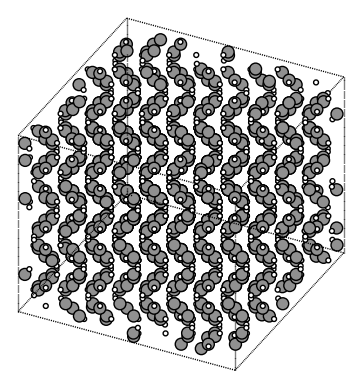

In [ ]:
from methods import *
# pyrefly: ignore [missing-import]
from ase.build import bulk
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.spacegroup import crystal
from ase.io import read, write
from ase.visualize.plot import plot_atoms
import os


PATH = 'benzene' 
# if not os.path.exists(PATH):
#     os.makedirs(PATH)
GENERAL_FILE_NAME = 'benzene'
PDB_FILE = f'{PATH}/{GENERAL_FILE_NAME}.pdb'
CIF_FILE = f'{PATH}/{GENERAL_FILE_NAME}.cif'

DEFECT_PDB_FILE = f'{PATH}/defect_{GENERAL_FILE_NAME}.pdb'

PE_CUTOFF = 16.0

# Change to make user input a molecule object. 
GEOMETRIES = {
    'H2O': "3\n\nO 0.0 0.0 0.117\nH 0.0 0.757 -0.469\nH 0.0 -0.757 -0.469\n",
    'Na':  "1\n\nNa 0.0 0.0 0.0\n",
    'Cl':  "1\n\nCl 0.0 0.0 0.0\n",
    'NaCl': "2\n\nNa 0.0 0.0 0.0\nCl 2.36 0.0 0.0\n",
    'C6H6': "12\n\nC 0.0000 1.3975 0.0000\nH 0.0000 2.4839 0.0000\nC -1.2094 0.6987 0.0000\nH -2.1619 1.2419 0.0000\nC -1.2094 -0.6987 0.0000\nH -2.1619 -1.2419 0.0000\nC 0.0000 -1.3975 0.0000\nH 0.0000 -2.4839 0.0000\nC 1.2094 -0.6987 0.0000\nH 2.1619 -1.2419 0.0000\nC 1.2094 0.6987 0.0000\nH 2.1619 1.2419 0.0000\n"
}

CHARGE_MAP = {'O': -2, 'C': 0, 'H': 0, 'Na': 1, 'Cl': -1}  

TARGET_SIZE = 50
TARGET_SHAPE = 'sc'

CUBOID_THRESHOLD = 0.3

_pattern = ['C']*24 + ['H']*24
print(f'DEBUG: _pattern {_pattern}')

PATTERN = {'BEN': _pattern}

##########################################################################################    
#                                Generate Ice Supercell                                               
##########################################################################################    

unit_cell = read(CIF_FILE)
# plot_atoms(unit_cell)

P = find_optimal_cell_shape(
        cell=unit_cell.cell, 
        target_size=TARGET_SIZE,
        target_shape=TARGET_SHAPE
    )

supercell = make_supercell(unit_cell, P)
plot_atoms(supercell)

write(f'{PDB_FILE}', supercell)

# qm_ids = get_centeroid_region(
#             filename=PDB_FILE,
#             patterns=PATTERN,
#             cuboid_threshold=CUBOID_THRESHOLD,
#             debug = True
#         )

#print(f'DEBUG: qm_ids {qm_ids}')

# NOTE: Draft.
collections = identify_connectivity_pdb(
    filename=PDB_FILE,
    bonds_length=[('C', 'C', 1.6), ('C', 'H', 1.2)],
    debug=False
)
# print(f'DEBUG: collections {collections}')

qm_ids = process_pdb_advanced(
    filename = PDB_FILE,
    mol_residues = {'BEN': [collections, 12]},
    qm_resname = 'LIG',
    qm_threshold = 0.1,
    debug=True,
    clear_unmatched = True
)

# process_pdb(
#     filename=PDB_FILE,
#     patterns=PATTERN,
#     qm_ids=qm_ids,
#     qm_resname='LIG'
# )

# minimum_image_unwrap(filename=PDB_FILE)

defect, up_candidate_qm = del_atoms_pdb(      
    filename=PDB_FILE,
    output_filename=DEFECT_PDB_FILE,
    delete_indecies=qm_ids[0], # Remove the first index collection. 
    qm_resname='LIG'
)

print(f'DEBUG: deleting atoms at indices: {qm_ids[0]}')
print(f'DEBUG: Updated qm list {up_candidate_qm}')
print(f'DEBUG: Removed atoms {defect}')
print(f'DEBUG: atoms removed count: {len(defect)}')

# plot_atoms(read(filename=DEFECT_PDB_FILE))

# ##########################################################################################    
# #                                 COMPUTE FORMATION ENERGY                                          
# ##########################################################################################    
# Construct XYZ geometry string directly from the extracted unrelaxed atoms (Option A)
n_atoms = len(defect)
defect_xyz = f"{n_atoms}\n\n"
for symbol, pos in zip(defect.get_chemical_symbols(), defect.get_positions()):
    defect_xyz += f"{symbol} {pos[0]:.8f} {pos[1]:.8f} {pos[2]:.8f}\n"

print("DEBUG: Derived real chemical potential geometry from extracted defect atoms.")

# Compute μ(C6H6) using the EXACT same unrelaxed geometry found inside the supercell
mu = calc_chemical_potential(
    species='CUSTOM', 
    basis_set='6-31G', 
    geometries={'CUSTOM': defect_xyz},
    dispersion = True
)

# Compute formation energy
E_f = calc_formation_energy( 
    filename_perf=PDB_FILE,
    filename_defect=DEFECT_PDB_FILE,
    qm_resname='LIG',
    chemical_potentials = {'BEN': (1, mu)},
    dispersion = True,
    debug=True,
    pe_cutoff=PE_CUTOFF,
    charge_map=CHARGE_MAP
)

# E_f.plot_band_diagram()